In [131]:
import numpy as np
import pickle
import cv2

import matplotlib.pyplot as plt

In [132]:
H, W = 512, 512

In [133]:
def plot_gradients(image, theta, stride):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")

    # compute arrow positions (center of each orientation block)
    theta = np.mod(theta, 2 * np.pi)
    ys, xs = np.mgrid[0:H:stride, 0:W:stride]
    U = np.cos(theta[::stride, ::stride])
    V = np.sin(theta[::stride, ::stride])

    # draw quiver with small width and pivot in the middle so arrows don't fill blocks
    plt.quiver(
        xs,
        ys,
        U,
        V,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=0.07,
        width=0.003,
        headaxislength=0,
        headlength=0,
        headwidth=0,
    )

    # plt.gca().invert_yaxis()
    plt.title("Blockwise Dominant Ridge Orientation")
    plt.axis("off")

[[  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]
 ...
 [  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]]
[[  0   0   0 ...   0   0   0]
 [  1   1   1 ...   1   1   1]
 [  2   2   2 ...   2   2   2]
 ...
 [509 509 509 ... 509 509 509]
 [510 510 510 ... 510 510 510]
 [511 511 511 ... 511 511 511]]
[[-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]
 ...
 [-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]]
[[-256 -256 -256 ... -256 -256 -256]
 [-255 -255 -255 ... -255 -255 -255]
 [-254 -254 -254 ... -254 -254 -254]
 ...
 [ 253  253  253 ...  253  253  253]
 [ 254  254  254 ...  254  254  254]
 [ 255  255  255 ...  255  255  255]]


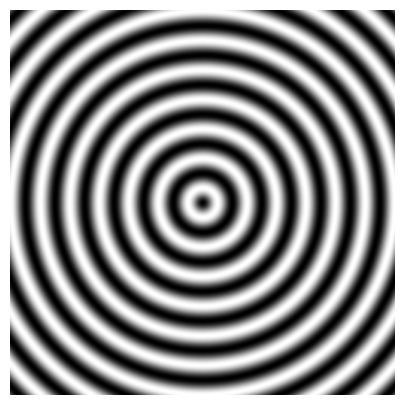

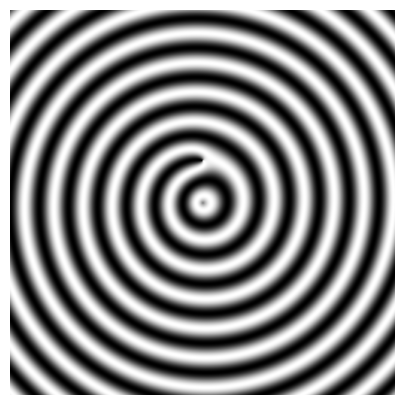

In [134]:
yy, xx = np.mgrid[:H, :W]
cx, cy = W // 2, H // 2
X = xx - cx
Y = yy - cy

def add_spiral_phase(psi, points, polarities):
    # points: list of (y,x); polarities: +1 for termination, -1 for bifurcation (convention)
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    out = psi.copy()
    for (yy, xx), p in zip(points, polarities):
        out += p * np.arctan2(Y-yy, X-xx)
    return out

print(xx)
print(yy)

print(X)
print(Y)

# radial phase
kappa = 0.16  # controls spacing of rings (ridges)
psi_c = kappa * np.sqrt(X * X + Y * Y)

psi_s = add_spiral_phase(psi_c, points=[(200, 256)], polarities=[+1])

# render ridges (dark)
I = 0.5 * (1.0 - np.cos(psi_c))
img = (I * 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

I_s = 0.5 * (1.0 - np.cos(psi_s))
img_s = (I_s * 255).astype(np.uint8)
plt.figure(figsize=(5, 5))
plt.imshow(img_s, cmap="gray")
plt.axis("off")
plt.show()

In [135]:
w = 8  # Block size

Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

Gx2 = Gx * Gx
Gy2 = Gy * Gy
Gxy = Gx * Gy

sum_Gx2 = cv2.boxFilter(Gx2, -1, (w, w), normalize=False)
sum_Gy2 = cv2.boxFilter(Gy2, -1, (w, w), normalize=False)
sum_Gxy = cv2.boxFilter(Gxy, -1, (w, w), normalize=False)

# Vx = sum_Gxy[w // 2 :: w, w // 2 :: w] * 2  # The original paper uses 2 * sum_Gxy
# Vy = sum_Gx2[w // 2 :: w, w // 2 :: w] - sum_Gy2[w // 2 :: w, w // 2 :: w]

Vx = 2 * sum_Gxy
Vy = sum_Gx2 - sum_Gy2

theta = 0.5 * np.arctan2(Vx, Vy)
Tx = np.cos(2 * theta)
Ty = np.sin(2 * theta)

Tprime_x = cv2.GaussianBlur(Tx, (5, 5), 0)
Tprime_y = cv2.GaussianBlur(Ty, (5, 5), 0)

theta_smoothed = 0.5 * np.arctan2(Tprime_y, Tprime_x)

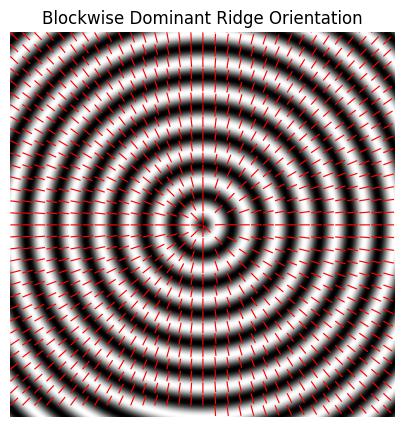

In [136]:
plot_gradients(img, theta_smoothed, stride=16)

In [137]:
# yy, xx  = np.mgrid[:H, :W]
# f = 0.015

# continuous_phase = 2 * np.pi * f * yy
# I = 0.5 * (1.0 - np.cos(continuous_phase))
# print(I.shape)
# img = (I * 255).astype(np.uint8)

# spiral_phase = add_spiral_phase(continuous_phase, points=[(200, 256)], polarities=[+1])

# plt.figure(figsize=(5, 5))
# plt.imshow(continuous_phase, cmap="gray")
# plt.axis("off")
# plt.show()

# plt.figure(figsize=(5, 5))
# plt.imshow(spiral_phase, cmap="gray")
# plt.axis("off")
# plt.show()

# plt.figure(figsize=(5, 5))
# plt.imshow(img, cmap="gray")
# plt.axis("off")
# plt.show()

# spiral_phase = 0.5 * (1.0 - np.cos(spiral_phase))
# img_s = (spiral_phase * 255).astype(np.uint8)
# plt.figure(figsize=(5, 5))
# plt.imshow(img_s, cmap="gray")
# plt.axis("off")
# plt.show()

In [138]:
def ridge_tangent(theta_edge):
    """If you estimated EDGE orientation, convert to RIDGE tangent: θ_ridge = θ_edge + π/2 mod π."""
    return (theta_edge + np.pi / 2.0) % np.pi


def build_v(theta_ridge, freq):
    """Target phase gradient v = ∇ψ = 2π f [cos θ, sin θ]."""
    vx = 2.0 * np.pi * freq * np.cos(theta_ridge)
    vy = 2.0 * np.pi * freq * np.sin(theta_ridge)
    return vx, vy


def div_centered(vx, vy):
    """Centered-difference divergence (periodic stencil; swap for one-sided if desired)."""
    dvx_dx = 0.5 * (np.roll(vx, -1, 1) - np.roll(vx, 1, 1))
    dvy_dy = 0.5 * (np.roll(vy, -1, 0) - np.roll(vy, 1, 0))
    return dvx_dx + dvy_dy


def render_from_phase(psi, dark_ridges=True):
    I = 0.5 * (1.0 - np.cos(psi)) if dark_ridges else 0.5 * (1.0 + np.cos(psi))
    return (np.clip(I, 0, 1) * 255).astype(np.uint8)

In [139]:
def phase_poisson_fft(theta_ridge, freq):
    """
    Solve Δψ = div(2π f [cosθ, sinθ]) with periodic BC via FFT.
    Returns ψ (mean-zero).
    """
    H, W = theta_ridge.shape
    vx, vy = build_v(theta_ridge, freq)
    div_v = div_centered(vx, vy)

    kx = 2 * np.pi * np.fft.fftfreq(W)
    ky = 2 * np.pi * np.fft.fftfreq(H)
    KX, KY = np.meshgrid(kx, ky)
    DEN = -(KX**2 + KY**2)

    DIV = np.fft.fft2(div_v)
    DEN[0, 0] = 1.0  # avoid division by zero at DC
    PSI = DIV / DEN
    PSI[0, 0] = 0.0  # fix arbitrary constant (mean-zero ψ)
    psi = np.real(np.fft.ifft2(PSI))
    return psi

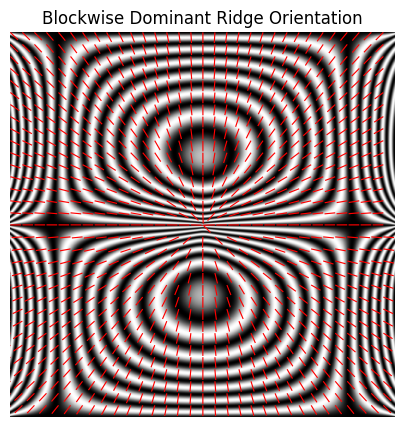

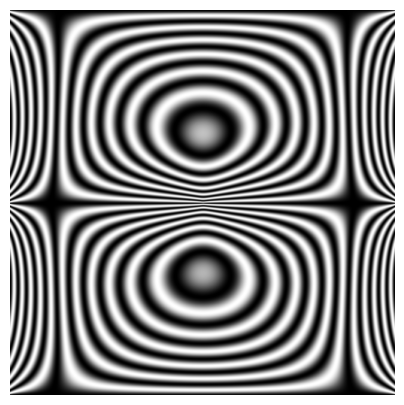

In [140]:
# theta_map = pickle.load(open("theta_smoothed.pkl", "rb"))

# Ensure we have per-pixel orientation and frequency maps at image resolution
C = np.cos(2.0 * theta_smoothed)
S = np.sin(2.0 * theta_smoothed)

C = cv2.resize(C, (W, H), interpolation=cv2.INTER_CUBIC)
S = cv2.resize(S, (W, H), interpolation=cv2.INTER_CUBIC)

# 3) Back to angle, then wrap to [0, π)
theta = 0.5 * np.arctan2(S, C)  # now in (-π/2, π/2]
theta_map = np.mod(theta, np.pi)  # -> [0, π)

freq_map = np.full_like(theta_map, 0.111)

psi_map = phase_poisson_fft(theta_map, freq_map)
ridge_img = render_from_phase(psi_map, dark_ridges=True)

plot_gradients(ridge_img, theta_map, stride=16)

plt.figure(figsize=(5, 5))
plt.imshow(ridge_img, cmap="gray")
plt.axis("off")
plt.show()

## Reconstruct from complex plane

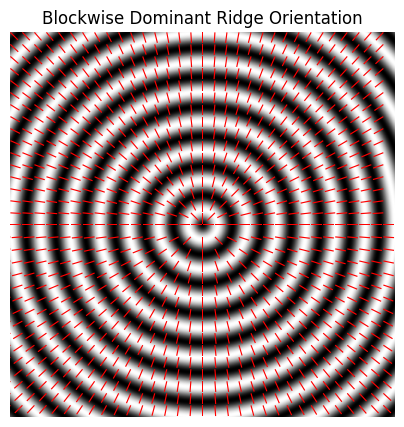

In [144]:
dpsi_dx = np.gradient(psi_c, axis=1)
dpsi_dy = np.gradient(psi_c, axis=0)

# phase gradient magnitude → local spatial frequency
freq_map = np.sqrt(dpsi_dx**2 + dpsi_dy**2) / (2 * np.pi)
# orientation (edge direction, in radians)
theta = np.arctan2(dpsi_dy, dpsi_dx)
theta = np.mod(theta, np.pi)
plot_gradients(img, theta, stride=16)

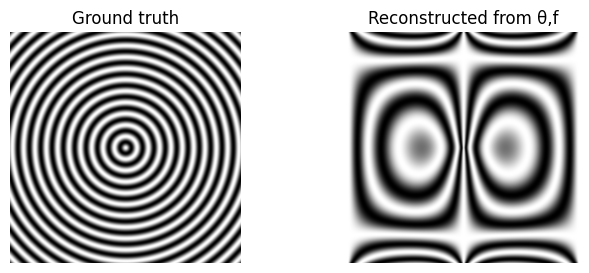

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq

# ---------- Ground-truth phase and image ----------
H = W = 512
yy, xx = np.mgrid[:H, :W]
cx, cy = W / 2, H / 2

k = 0.25
psi_true = k * np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
I_true = 0.5 * (1 + np.cos(psi_true))

# ---------- Derive θ (ridge), then gradient orientation θ_grad, and f ----------
# Phase gradient:
dψdx = np.gradient(psi_true, axis=1)  # x = cols
dψdy = np.gradient(psi_true, axis=0)  # y = rows
mag = np.hypot(dψdx, dψdy)

# Frequency in cycles/pixel
freq = mag / (2 * np.pi)

# Ridge orientation (tangent) is perpendicular to grad
theta_ridge = (np.arctan2(dψdy, dψdx) + np.pi / 2.0) % np.pi

# For phase reconstruction we need the GRADIENT direction:
theta_grad = (theta_ridge + np.pi / 2.0) % (2 * np.pi)  # = atan2(dψdy,dψdx)

# ---------- Build target gradient field v = ∇ψ = 2π f [cos θ_grad, sin θ_grad] ----------
vx = 2 * np.pi * freq * np.cos(theta_grad)
vy = 2 * np.pi * freq * np.sin(theta_grad)


# ---------- Periodic divergence (MUST match FFT BCs) ----------
def div_periodic(vx, vy):
    dvx_dx = 0.5 * (np.roll(vx, -1, axis=1) - np.roll(vx, 1, axis=1))
    dvy_dy = 0.5 * (np.roll(vy, -1, axis=0) - np.roll(vy, 1, axis=0))
    return dvx_dx + dvy_dy


div_v = div_periodic(vx, vy)

# ---------- Poisson solve with FFT (periodic) ----------
kx = 2 * np.pi * fftfreq(W)  # radians/sample
ky = 2 * np.pi * fftfreq(H)
KX, KY = np.meshgrid(kx, ky)
DEN = -(KX**2 + KY**2)

DIV = fft2(div_v)
DEN[0, 0] = 1.0  # avoid divide-by-zero at DC
PSI = DIV / DEN
PSI[0, 0] = 0.0  # fix arbitrary constant → mean-zero phase

psi_rec = np.real(ifft2(PSI))

# ---------- Render reconstructed rings ----------
I_rec = 0.5 * (1 + np.cos(psi_rec))

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(I_true, cmap="gray")
plt.title("Ground truth")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(I_rec, cmap="gray")
plt.title("Reconstructed from θ,f")
plt.axis("off")
plt.show()